# Match Prediction With Rich Multi-Competition Team Form

This notebook trains a standalone football prediction pipeline across the
competitions in the merged rich stats dataset. The pipeline is designed as
a practical ML workflow: clean the data, build leakage-safe pre-match
features, train models on past fixtures, evaluate on future fixtures, and
save a reusable prediction artifact.

The main match result is modeled as one multiclass 1X2 target:

- `home_win`
- `draw`
- `away_win`

Two separate binary XGBoost classifiers model win-either-half outcomes:

- `home_wins_either_half`
- `away_wins_either_half`

It uses the rich match stats dataset only. After loading the merged file,
matches are filtered until every remaining team has at least ten matches.
Every model receives the same pre-match feature table built from rolling
team history, with current match data excluded by construction. The final
decision thresholds are hardcoded constants.

Evaluation is intentionally visible: the notebook reports train/test
accuracy, generalisation gaps, class-level metrics, confusion-matrix
behavior, feature importance, decision precision, and decision coverage.

| Feature name | Meaning |
|---|---|
| `elo_difference` | Home Elo minus away Elo before the match updates ratings. |
| `home_points_at_home` | Home team's mean points over its last home matches. |
| `away_points_at_away` | Away team's mean points over its last away matches. |
| `home_goals_scored_form` | Home team's mean goals scored across recent matches. |
| `away_goals_scored_form` | Away team's mean goals scored across recent matches. |
| `points_form_difference` | Home recent points minus away recent points. |
| `home_attack_vs_away_defence` | Home scoring form minus away conceding form. |
| `away_attack_vs_home_defence` | Away scoring form minus home conceding form. |
| `goal_difference_form_gap` | Home goal-difference form minus away goal-difference form. |
| `shots_on_target_difference` | Home shots-on-target form minus away shots-on-target form. |
| `corners_difference` | Home corners form minus away corners form. |
| `rest_days_difference` | Home rest days minus away rest days. |
| `shot_accuracy_difference` | Home shot-accuracy form minus away shot-accuracy form. |
| `possession_difference` | Home possession form minus away possession form. |
| `fouls_difference` | Home fouls form minus away fouls form. |
| `shots_on_target_conceded_difference` | Home shots-on-target conceded form minus away shots-on-target conceded form. |

## 1. Imports and Constants

Paths, model settings, Elo settings, feature names, filtering settings,
evaluation helpers, and hardcoded decision thresholds.

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import joblib
import numpy
import pandas
import matplotlib.pyplot as pyplot
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

project_root = Path.cwd()
if not (project_root / "datasets").exists():
    project_root = project_root.parent

data_path = project_root / "datasets" / "rich_stats" / "league_matches_stats.csv"
models_directory = project_root / "models"
artifact_path = models_directory / "match_1x2_pred.joblib"

window = 3
minimum_team_matches = 10
initial_elo = 1500.0
elo_k = 20.0
home_advantage = 65.0

split_date = pandas.Timestamp("2026-01-01")
random_seed = 42
xgboost_parameters = {"random_state": random_seed}

decision_thresholds = {
    "minimum_outright_probability": 0.65,
    "minimum_outright_margin": 0.20,
    "minimum_either_half_probability": 0.70,
}

feature_names = [
    "elo_difference",
    "home_points_at_home",
    "away_points_at_away",
    "home_goals_scored_form",
    "away_goals_scored_form",
    "points_form_difference",
    "home_attack_vs_away_defence",
    "away_attack_vs_home_defence",
    "goal_difference_form_gap",
    "shots_on_target_difference",
    "corners_difference",
    "rest_days_difference",
    "shot_accuracy_difference",
    "possession_difference",
    "fouls_difference",
    "shots_on_target_conceded_difference",
]

match_result_labels = {
    0: "home_win",
    1: "draw",
    2: "away_win",
}
binary_target_names = [
    "home_wins_either_half",
    "away_wins_either_half",
]
target_names = ["match_result"] + binary_target_names

raw_columns_used = [
    "match_id",
    "season",
    "country",
    "competition",
    "date_utc",
    "home_team",
    "away_team",
    "home_score_ft",
    "away_score_ft",
    "home_score_ht",
    "away_score_ht",
    "home_shots_on_target_ft",
    "away_shots_on_target_ft",
    "home_total_shots_ft",
    "away_total_shots_ft",
    "home_corner_kicks_ft",
    "away_corner_kicks_ft",
    "home_ball_possession_ft",
    "away_ball_possession_ft",
    "home_fouls_ft",
    "away_fouls_ft",
]

pandas.set_option("display.max_columns", 80)
pandas.set_option("display.max_rows", 80)

## 2. Load, Filter, Sort, and Derive Targets

The merged rich dataset is loaded for all competitions. Team names are used
exactly as they appear in the file. After required columns are present, the
data is repeatedly filtered until every remaining team has at least ten
total appearances.

In [2]:
def remove_matches_with_low_history_teams(match_frame, minimum_matches=minimum_team_matches):
    filtered_matches = match_frame.copy()
    filter_iterations = []

    while True:
        team_match_counts = pandas.concat([
            filtered_matches["home_team"],
            filtered_matches["away_team"],
        ]).value_counts()
        eligible_team_names = team_match_counts[team_match_counts >= minimum_matches].index
        next_filtered_matches = filtered_matches[
            filtered_matches["home_team"].isin(eligible_team_names)
            & filtered_matches["away_team"].isin(eligible_team_names)
        ].copy()

        filter_iterations.append({
            "iteration": len(filter_iterations) + 1,
            "matches_before": len(filtered_matches),
            "matches_after": len(next_filtered_matches),
            "teams_before": len(team_match_counts),
            "eligible_teams": len(eligible_team_names),
            "minimum_team_matches_before": int(team_match_counts.min()) if len(team_match_counts) else 0,
            "matches_removed": len(filtered_matches) - len(next_filtered_matches),
        })

        if len(next_filtered_matches) == len(filtered_matches):
            break
        filtered_matches = next_filtered_matches

    final_team_match_counts = pandas.concat([
        filtered_matches["home_team"],
        filtered_matches["away_team"],
    ]).value_counts()
    return filtered_matches, final_team_match_counts, pandas.DataFrame(filter_iterations)


def load_matches(path=data_path):
    # Read only the raw columns consumed by this notebook.
    matches = pandas.read_csv(path, usecols=raw_columns_used).copy()

    # Parse kickoff time and keep the original date_utc column name.
    matches["date_utc"] = (
        pandas.to_datetime(matches["date_utc"], errors="coerce", utc=True)
        .dt.tz_convert(None)
    )

    numeric_raw_columns = [
        "home_score_ft",
        "away_score_ft",
        "home_score_ht",
        "away_score_ht",
        "home_shots_on_target_ft",
        "away_shots_on_target_ft",
        "home_total_shots_ft",
        "away_total_shots_ft",
        "home_corner_kicks_ft",
        "away_corner_kicks_ft",
        "home_ball_possession_ft",
        "away_ball_possession_ft",
        "home_fouls_ft",
        "away_fouls_ft",
    ]
    for raw_column_name in numeric_raw_columns:
        matches[raw_column_name] = pandas.to_numeric(matches[raw_column_name], errors="coerce")

    rows_loaded = len(matches)
    matches = matches.dropna(subset=raw_columns_used).copy()
    rows_after_required_columns = len(matches)

    matches, team_match_counts, team_filter_summary = remove_matches_with_low_history_teams(matches)
    matches = matches.sort_values(["date_utc", "match_id"]).reset_index(drop=True)

    # Main 1X2 outcome and either-half labels.
    matches["home_win"] = (matches["home_score_ft"] > matches["away_score_ft"]).astype(int)
    matches["away_win"] = (matches["away_score_ft"] > matches["home_score_ft"]).astype(int)
    matches["draw"] = matches["home_score_ft"].eq(matches["away_score_ft"]).astype(int)
    matches["match_result"] = numpy.where(
        matches["home_win"].eq(1),
        0,
        numpy.where(matches["away_win"].eq(1), 2, 1),
    ).astype(int)

    home_second_half_goals = matches["home_score_ft"] - matches["home_score_ht"]
    away_second_half_goals = matches["away_score_ft"] - matches["away_score_ht"]
    matches["home_wins_either_half"] = (
        (matches["home_score_ht"] > matches["away_score_ht"])
        | (home_second_half_goals > away_second_half_goals)
    ).astype(int)
    matches["away_wins_either_half"] = (
        (matches["away_score_ht"] > matches["home_score_ht"])
        | (away_second_half_goals > home_second_half_goals)
    ).astype(int)

    matches["home_points"] = numpy.where(
        matches["home_win"].eq(1),
        3,
        numpy.where(matches["away_win"].eq(1), 0, 1),
    )
    matches["away_points"] = numpy.where(
        matches["away_win"].eq(1),
        3,
        numpy.where(matches["home_win"].eq(1), 0, 1),
    )
    load_summary = {
        "rows_loaded": rows_loaded,
        "rows_after_required_columns": rows_after_required_columns,
        "rows_after_team_filter": len(matches),
        "rows_removed_for_required_columns": rows_loaded - rows_after_required_columns,
        "rows_removed_for_low_history_teams": rows_after_required_columns - len(matches),
        "remaining_teams": len(team_match_counts),
        "minimum_remaining_team_matches": int(team_match_counts.min()) if len(team_match_counts) else 0,
    }
    return matches, team_match_counts, team_filter_summary, load_summary


matches, team_match_counts, team_filter_summary, load_summary = load_matches()

print("Cleaned dataset shape and date range")
print("Rows and columns:", matches.shape)
print("Data source:", data_path)
print("Date range:", matches["date_utc"].min().date(), "to", matches["date_utc"].max().date())

print("\nData loading and filtering summary")
display(pandas.DataFrame([load_summary]))

print("\nRaw train/test row counts before rolling-feature rows are removed")
display(pandas.DataFrame([{
    "training_rows": int((matches["date_utc"] < split_date).sum()),
    "test_rows": int((matches["date_utc"] >= split_date).sum()),
}]))

print("\n1X2 target distribution after cleaning")
display(
    matches["match_result"]
    .map(match_result_labels)
    .value_counts()
    .rename_axis("result")
    .rename("matches")
    .to_frame()
)

print("\nCompetition coverage after cleaning")
display(matches["competition"].value_counts().rename("matches").to_frame())

print("\nLow-history team filter iterations")
display(team_filter_summary)

print("\nPreview of the cleaned match table")
display(matches.head())

Cleaned dataset shape and date range
Rows and columns: (14721, 29)
Data source: C:\PROJECTS\Python\ML\betting\datasets\rich_stats\league_matches_stats.csv
Date range: 2020-08-18 to 2026-05-30

Data loading and filtering summary


,rows_loaded,rows_after_required_columns,rows_after_team_filter,rows_removed_for_required_columns,rows_removed_for_low_history_teams,remaining_teams,minimum_remaining_team_matches
0,15645,15627,14721,18,906,322,10



Raw train/test row counts before rolling-feature rows are removed


,training_rows,test_rows
0,13563,1158



1X2 target distribution after cleaning


...

,matches
competition,
Premier League,2280
La Liga,2280
Serie A,2280
Ligue 1,2067
Bundesliga,1841
UEFA Conference League,1361
UEFA Champions League,1334
UEFA Europa League,1278



Low-history team filter iterations


,iteration,matches_before,matches_after,teams_before,eligible_teams,minimum_team_matches_before,matches_removed
0,1,15627,14981,532,356,1,646
1,2,14981,14802,356,332,5,179
2,3,14802,14738,332,324,6,64
3,4,14738,14730,324,323,8,8
4,5,14730,14721,323,322,9,9
5,6,14721,14721,322,322,10,0



Preview of the cleaned match table


,match_id,season,country,competition,date_utc,home_team,away_team,home_score_ft,home_total_shots_ft,home_shots_on_target_ft,home_ball_possession_ft,home_corner_kicks_ft,home_fouls_ft,away_score_ft,away_total_shots_ft,away_shots_on_target_ft,away_ball_possession_ft,away_corner_kicks_ft,away_fouls_ft,home_score_ht,away_score_ht,home_win,away_win,draw,match_result,home_wins_either_half,away_wins_either_half,home_points,away_points
0,boVnZQcQ,2020-2021,europe,UEFA Champions League,2020-08-18 17:00:00,legia,linfield,1,20,11,60.0,9,14.0,0,6,2,40.0,1,11.0,0.0,0.0,1,0,0,0,1,0,3,0
1,h0hNfMEU,2020-2021,europe,UEFA Champions League,2020-08-19 15:00:00,ararat-armenia,omonia,0,6,1,52.0,3,18.0,0,2,1,48.0,4,19.0,0.0,0.0,0,0,1,1,0,0,1,1
2,KYvGdrpI,2020-2021,europe,UEFA Champions League,2020-08-19 16:00:00,molde,kups,5,17,9,52.0,7,5.0,0,14,6,48.0,3,9.0,2.0,0.0,1,0,0,0,1,0,3,0
3,QmNyEqFh,2020-2021,europe,UEFA Champions League,2020-08-19 17:00:00,dinamo_tbilisi,kf_tirana,0,6,2,65.0,10,10.0,2,8,6,35.0,2,19.0,0.0,1.0,0,1,0,2,0,1,0,3
4,jyfT3aio,2020-2021,europe,UEFA Champions League,2020-08-19 17:00:00,maccabi_tel_aviv,riga_fc,2,24,9,57.0,4,10.0,0,9,2,43.0,5,12.0,0.0,0.0,1,0,0,0,1,0,3,0


## 3. Elo

The Elo difference is recorded before each match result updates the two
team ratings.

In [3]:
def add_elo_features(match_frame, initial_elo_value=initial_elo, elo_k_value=elo_k, home_advantage_value=home_advantage):
    team_ratings = {}
    elo_records = []

    for match_record in match_frame.sort_values(["date_utc", "match_id"]).itertuples(index=False):
        home_team = match_record.home_team
        away_team = match_record.away_team
        home_rating = float(team_ratings.get(home_team, initial_elo_value))
        away_rating = float(team_ratings.get(away_team, initial_elo_value))

        expected_home_result = 1.0 / (
            1.0 + 10.0 ** (-((home_rating + home_advantage_value) - away_rating) / 400.0)
        )
        actual_home_result = 1.0 if match_record.home_win else 0.0 if match_record.away_win else 0.5
        rating_change = elo_k_value * (actual_home_result - expected_home_result)

        elo_records.append({
            "match_id": match_record.match_id,
            "elo_difference": home_rating - away_rating,
        })

        team_ratings[home_team] = home_rating + rating_change
        team_ratings[away_team] = away_rating - rating_change

    elo_frame = pandas.DataFrame(elo_records)
    matches_with_elo = match_frame.merge(elo_frame, on="match_id", how="left")
    matches_with_elo = matches_with_elo.sort_values(["date_utc", "match_id"]).reset_index(drop=True)
    return matches_with_elo, dict(team_ratings)

## 4. Team-Perspective Rows and Rolling Form

Each fixture becomes one row for the home team and one row for the away
team. Rolling means use previous matches only.

In [4]:
def divide_safely(numerator, denominator):
    denominator_as_array = numpy.asarray(denominator, dtype=float)
    numerator_as_array = numpy.asarray(numerator, dtype=float)
    return numpy.divide(
        numerator_as_array,
        denominator_as_array,
        out=numpy.zeros_like(numerator_as_array, dtype=float),
        where=denominator_as_array != 0,
    )


def make_team_match_rows(match_frame):
    # Home-team perspective.
    home_team_rows = pandas.DataFrame({
        "match_id": match_frame["match_id"],
        "season": match_frame["season"],
        "date_utc": match_frame["date_utc"],
        "team": match_frame["home_team"],
        "opponent": match_frame["away_team"],
        "venue": "home",
        "goals_scored": match_frame["home_score_ft"],
        "goals_conceded": match_frame["away_score_ft"],
        "points": match_frame["home_points"],
        "shots_on_target": match_frame["home_shots_on_target_ft"],
        "shots_on_target_conceded": match_frame["away_shots_on_target_ft"],
        "total_shots": match_frame["home_total_shots_ft"],
        "shot_accuracy": divide_safely(
            match_frame["home_shots_on_target_ft"],
            match_frame["home_total_shots_ft"],
        ),
        "corners": match_frame["home_corner_kicks_ft"],
        "possession": match_frame["home_ball_possession_ft"],
        "fouls": match_frame["home_fouls_ft"],
        "won_either_half": match_frame["home_wins_either_half"],
    })

    # Away-team perspective with the same self-describing metric names.
    away_team_rows = pandas.DataFrame({
        "match_id": match_frame["match_id"],
        "season": match_frame["season"],
        "date_utc": match_frame["date_utc"],
        "team": match_frame["away_team"],
        "opponent": match_frame["home_team"],
        "venue": "away",
        "goals_scored": match_frame["away_score_ft"],
        "goals_conceded": match_frame["home_score_ft"],
        "points": match_frame["away_points"],
        "shots_on_target": match_frame["away_shots_on_target_ft"],
        "shots_on_target_conceded": match_frame["home_shots_on_target_ft"],
        "total_shots": match_frame["away_total_shots_ft"],
        "shot_accuracy": divide_safely(
            match_frame["away_shots_on_target_ft"],
            match_frame["away_total_shots_ft"],
        ),
        "corners": match_frame["away_corner_kicks_ft"],
        "possession": match_frame["away_ball_possession_ft"],
        "fouls": match_frame["away_fouls_ft"],
        "won_either_half": match_frame["away_wins_either_half"],
    })

    team_match_rows = pandas.concat([home_team_rows, away_team_rows], ignore_index=True)
    team_match_rows["goal_difference"] = (
        team_match_rows["goals_scored"] - team_match_rows["goals_conceded"]
    )
    return team_match_rows.sort_values(["team", "date_utc", "match_id"]).reset_index(drop=True)


rolling_metric_names = [
    "points",
    "goals_scored",
    "goals_conceded",
    "shots_on_target",
    "shots_on_target_conceded",
    "total_shots",
    "shot_accuracy",
    "corners",
    "possession",
    "fouls",
    "goal_difference",
    "won_either_half",
]
rolling_feature_names = [f"rolling_{metric_name}" for metric_name in rolling_metric_names]


def add_rolling_team_form(team_match_rows, rolling_window=window):
    # All-venue form for each team, excluding the current match.
    team_form_parts = []
    for team_name, team_history in team_match_rows.groupby("team", sort=False):
        ordered_team_history = team_history.sort_values(["date_utc", "match_id"]).copy()
        ordered_team_history[rolling_feature_names] = (
            ordered_team_history[rolling_metric_names]
            .rolling(rolling_window, closed="left")
            .mean()
        )
        ordered_team_history["rest_days"] = ordered_team_history["date_utc"].diff().dt.days
        team_form_parts.append(ordered_team_history)

    team_form_with_all_venues = pandas.concat(team_form_parts, ignore_index=True)

    # Venue-specific points form, again excluding the current match.
    venue_form_parts = []
    for _, venue_history in team_form_with_all_venues.groupby(["team", "venue"], sort=False):
        ordered_venue_history = venue_history.sort_values(["date_utc", "match_id"]).copy()
        ordered_venue_history["rolling_points_at_venue"] = (
            ordered_venue_history["points"]
            .rolling(rolling_window, closed="left")
            .mean()
        )
        venue_form_parts.append(ordered_venue_history)

    team_form = pandas.concat(venue_form_parts, ignore_index=True)
    return team_form.sort_values(["date_utc", "match_id", "venue"]).reset_index(drop=True)

## 5. Assemble Feature Table

Home-side and away-side rolling rows are merged back onto each match,
then the sixteen model features are calculated.

In [5]:
def build_feature_table(match_frame):
    matches_with_elo, final_team_ratings = add_elo_features(match_frame)
    team_match_rows = make_team_match_rows(matches_with_elo)
    rolling_team_form = add_rolling_team_form(team_match_rows)

    rolling_columns_for_merge = [
        "match_id",
        "team",
        "rolling_points",
        "rolling_goals_scored",
        "rolling_goals_conceded",
        "rolling_shots_on_target",
        "rolling_shots_on_target_conceded",
        "rolling_shot_accuracy",
        "rolling_corners",
        "rolling_possession",
        "rolling_fouls",
        "rolling_goal_difference",
        "rolling_points_at_venue",
        "rest_days",
    ]

    home_selected_form = rolling_team_form[
        rolling_team_form["venue"].eq("home")
    ][rolling_columns_for_merge].copy()
    home_rolling_form = pandas.DataFrame({
        "match_id": home_selected_form["match_id"],
        "home_team_check": home_selected_form["team"],
        "home_rolling_points": home_selected_form["rolling_points"],
        "home_rolling_goals_scored": home_selected_form["rolling_goals_scored"],
        "home_rolling_goals_conceded": home_selected_form["rolling_goals_conceded"],
        "home_rolling_shots_on_target": home_selected_form["rolling_shots_on_target"],
        "home_rolling_shots_on_target_conceded": home_selected_form["rolling_shots_on_target_conceded"],
        "home_rolling_shot_accuracy": home_selected_form["rolling_shot_accuracy"],
        "home_rolling_corners": home_selected_form["rolling_corners"],
        "home_rolling_possession": home_selected_form["rolling_possession"],
        "home_rolling_fouls": home_selected_form["rolling_fouls"],
        "home_rolling_goal_difference": home_selected_form["rolling_goal_difference"],
        "home_rolling_points_at_home": home_selected_form["rolling_points_at_venue"],
        "home_rest_days": home_selected_form["rest_days"],
    })

    away_selected_form = rolling_team_form[
        rolling_team_form["venue"].eq("away")
    ][rolling_columns_for_merge].copy()
    away_rolling_form = pandas.DataFrame({
        "match_id": away_selected_form["match_id"],
        "away_team_check": away_selected_form["team"],
        "away_rolling_points": away_selected_form["rolling_points"],
        "away_rolling_goals_scored": away_selected_form["rolling_goals_scored"],
        "away_rolling_goals_conceded": away_selected_form["rolling_goals_conceded"],
        "away_rolling_shots_on_target": away_selected_form["rolling_shots_on_target"],
        "away_rolling_shots_on_target_conceded": away_selected_form["rolling_shots_on_target_conceded"],
        "away_rolling_shot_accuracy": away_selected_form["rolling_shot_accuracy"],
        "away_rolling_corners": away_selected_form["rolling_corners"],
        "away_rolling_possession": away_selected_form["rolling_possession"],
        "away_rolling_fouls": away_selected_form["rolling_fouls"],
        "away_rolling_goal_difference": away_selected_form["rolling_goal_difference"],
        "away_rolling_points_at_away": away_selected_form["rolling_points_at_venue"],
        "away_rest_days": away_selected_form["rest_days"],
    })

    feature_table = matches_with_elo.merge(home_rolling_form, on="match_id", how="left")
    feature_table = feature_table.merge(away_rolling_form, on="match_id", how="left")

    feature_table["home_points_at_home"] = feature_table["home_rolling_points_at_home"]
    feature_table["away_points_at_away"] = feature_table["away_rolling_points_at_away"]
    feature_table["home_goals_scored_form"] = feature_table["home_rolling_goals_scored"]
    feature_table["away_goals_scored_form"] = feature_table["away_rolling_goals_scored"]
    feature_table["points_form_difference"] = (
        feature_table["home_rolling_points"] - feature_table["away_rolling_points"]
    )
    feature_table["home_attack_vs_away_defence"] = (
        feature_table["home_rolling_goals_scored"] - feature_table["away_rolling_goals_conceded"]
    )
    feature_table["away_attack_vs_home_defence"] = (
        feature_table["away_rolling_goals_scored"] - feature_table["home_rolling_goals_conceded"]
    )
    feature_table["goal_difference_form_gap"] = (
        feature_table["home_rolling_goal_difference"] - feature_table["away_rolling_goal_difference"]
    )
    feature_table["shots_on_target_difference"] = (
        feature_table["home_rolling_shots_on_target"] - feature_table["away_rolling_shots_on_target"]
    )
    feature_table["corners_difference"] = (
        feature_table["home_rolling_corners"] - feature_table["away_rolling_corners"]
    )
    feature_table["rest_days_difference"] = (
        feature_table["home_rest_days"] - feature_table["away_rest_days"]
    )
    feature_table["shot_accuracy_difference"] = (
        feature_table["home_rolling_shot_accuracy"] - feature_table["away_rolling_shot_accuracy"]
    )
    feature_table["possession_difference"] = (
        feature_table["home_rolling_possession"] - feature_table["away_rolling_possession"]
    )
    feature_table["fouls_difference"] = (
        feature_table["home_rolling_fouls"] - feature_table["away_rolling_fouls"]
    )
    feature_table["shots_on_target_conceded_difference"] = (
        feature_table["home_rolling_shots_on_target_conceded"]
        - feature_table["away_rolling_shots_on_target_conceded"]
    )

    return feature_table, team_match_rows, rolling_team_form, final_team_ratings


feature_table, team_match_rows, rolling_team_form, final_team_ratings = build_feature_table(matches)
model_data = feature_table.dropna(subset=feature_names).copy()

feature_build_summary = pandas.DataFrame([{
    "rows_before_dropping_no_history_features": len(feature_table),
    "rows_after_dropping_no_history_features": len(model_data),
    "rows_dropped": len(feature_table) - len(model_data),
    "features_used": len(feature_names),
}])

print("Rolling feature build summary")
display(feature_build_summary)

print("\nModeling table preview")
display(model_data[["season", "competition", "date_utc", "home_team", "away_team"] + target_names + feature_names].head())

Rolling feature build summary


,rows_before_dropping_no_history_features,rows_after_dropping_no_history_features,rows_dropped,features_used
0,14721,13354,1367,16



Modeling table preview


,season,competition,date_utc,home_team,away_team,match_result,home_wins_either_half,away_wins_either_half,elo_difference,home_points_at_home,away_points_at_away,home_goals_scored_form,away_goals_scored_form,points_form_difference,home_attack_vs_away_defence,away_attack_vs_home_defence,goal_difference_form_gap,shots_on_target_difference,corners_difference,rest_days_difference,shot_accuracy_difference,possession_difference,fouls_difference,shots_on_target_conceded_difference
296,2020-2021,Ligue 1,2020-10-16 17:00:00,dijon,rennes,1,1,1,-84.672340,0.333333,2.333333,0.666667,2.333333,-2.000000,-0.333333,0.333333,-2.666667,-1.000000,-3.666667,0.0,-0.015873,-17.666667,3.333333,2.666667
297,2020-2021,Ligue 1,2020-10-16 19:00:00,nimes,psg,2,0,1,-18.318010,1.333333,2.000000,0.666667,3.666667,-1.333333,0.333333,3.333333,-3.000000,-5.666667,-3.666667,-2.0,-0.231960,-15.666667,2.333333,0.000000
322,2020-2021,Ligue 1,2020-10-18 11:00:00,strasbourg,lyon,2,1,1,-35.368968,1.000000,0.666667,1.000000,0.666667,0.000000,0.333333,-1.333333,-1.000000,0.666667,-4.000000,0.0,0.131161,-21.333333,-2.000000,2.333333
328,2020-2021,Ligue 1,2020-10-18 13:00:00,angers,metz,1,0,0,7.762450,2.000000,0.333333,1.666667,2.000000,-1.333333,0.666667,-2.000000,-3.333333,-1.666667,-2.000000,1.0,-0.039683,-3.666667,-1.333333,5.333333
332,2020-2021,Ligue 1,2020-10-18 15:00:00,st_etienne,nice,2,0,1,1.034258,2.000000,1.333333,0.666667,0.666667,-1.000000,-0.666667,-1.666667,-1.000000,-1.666667,-4.000000,1.0,0.311152,-17.333333,0.333333,0.666667


## 6. Train and Test Split

Matches before 2026-01-01 train the models. Matches on or after that date
are the test set.

In [6]:
training_matches = model_data[model_data["date_utc"] < split_date].copy()
test_matches = model_data[model_data["date_utc"] >= split_date].copy()


def result_rate(frame, result_code):
    return float(frame["match_result"].eq(result_code).mean()) if len(frame) else numpy.nan


split_summary = pandas.DataFrame([
    {
        "split": "training",
        "rows": len(training_matches),
        "start": training_matches["date_utc"].min().date(),
        "end": training_matches["date_utc"].max().date(),
        "home_win_rate": result_rate(training_matches, 0),
        "draw_rate": result_rate(training_matches, 1),
        "away_win_rate": result_rate(training_matches, 2),
        "home_wins_either_half_rate": training_matches["home_wins_either_half"].mean(),
        "away_wins_either_half_rate": training_matches["away_wins_either_half"].mean(),
    },
    {
        "split": "test",
        "rows": len(test_matches),
        "start": test_matches["date_utc"].min().date(),
        "end": test_matches["date_utc"].max().date(),
        "home_win_rate": result_rate(test_matches, 0),
        "draw_rate": result_rate(test_matches, 1),
        "away_win_rate": result_rate(test_matches, 2),
        "home_wins_either_half_rate": test_matches["home_wins_either_half"].mean(),
        "away_wins_either_half_rate": test_matches["away_wins_either_half"].mean(),
    },
])

print("Temporal train/test split summary")
print(f"Split date: {split_date.date()}")
display(split_summary.round(3))

Temporal train/test split summary
Split date: 2026-01-01


,split,rows,start,end,home_win_rate,draw_rate,away_win_rate,home_wins_either_half_rate,away_wins_either_half_rate
0,training,12196,2020-10-16,2025-12-30,0.442,0.244,0.314,0.579,0.464
1,test,1158,2026-01-01,2026-05-30,0.439,0.249,0.313,0.585,0.459


## 7. Train XGBoost Models

The main result uses one multiclass 1X2 classifier. The two either-half
targets remain separate binary classifiers.

In [7]:
def make_xgboost_classifier():
    return XGBClassifier(**xgboost_parameters)


training_feature_matrix = training_matches[feature_names]
test_feature_matrix = test_matches[feature_names]

trained_models = {}
prediction_store = {}
model_accuracy_records = []

match_result_model = make_xgboost_classifier()
match_result_model.fit(training_feature_matrix, training_matches["match_result"])
trained_models["match_result"] = match_result_model

for split_name, split_frame, split_features in [
    ("training", training_matches, training_feature_matrix),
    ("test", test_matches, test_feature_matrix),
]:
    predictions = match_result_model.predict(split_features)
    prediction_store[("match_result", split_name)] = predictions
    model_accuracy_records.append({
        "target": "match_result",
        "model_type": "multiclass_1x2",
        "split": split_name,
        "rows": len(split_frame),
        "accuracy": accuracy_score(split_frame["match_result"], predictions),
        "positive_rate": numpy.nan,
    })

for target_name in binary_target_names:
    xgboost_classifier = make_xgboost_classifier()
    xgboost_classifier.fit(training_feature_matrix, training_matches[target_name])
    trained_models[target_name] = xgboost_classifier

    for split_name, split_frame, split_features in [
        ("training", training_matches, training_feature_matrix),
        ("test", test_matches, test_feature_matrix),
    ]:
        predictions = xgboost_classifier.predict(split_features)
        prediction_store[(target_name, split_name)] = predictions
        model_accuracy_records.append({
            "target": target_name,
            "model_type": "binary",
            "split": split_name,
            "rows": len(split_frame),
            "accuracy": accuracy_score(split_frame[target_name], predictions),
            "positive_rate": split_frame[target_name].mean(),
        })

model_accuracy_table = pandas.DataFrame(model_accuracy_records)
accuracy_pivot_table = (
    model_accuracy_table
    .pivot(index="target", columns="split", values="accuracy")
    .round(3)
)

print("Model accuracy by split")
display(accuracy_pivot_table)

print("\nDetailed model accuracy table")
display(model_accuracy_table.round(3))

Model accuracy by split


split,test,training
target,,
away_wins_either_half,0.599,0.875
home_wins_either_half,0.623,0.870
match_result,0.479,0.820



Detailed model accuracy table


,target,model_type,split,rows,accuracy,positive_rate
0,match_result,multiclass_1x2,training,12196,0.820,NaN
1,match_result,multiclass_1x2,test,1158,0.479,NaN
2,home_wins_either_half,binary,training,12196,0.870,0.579
3,home_wins_either_half,binary,test,1158,0.623,0.585
4,away_wins_either_half,binary,training,12196,0.875,0.464
5,away_wins_either_half,binary,test,1158,0.599,0.459


## 8. Model Evaluation Diagnostics

These diagnostics check whether the models are learning patterns that
transfer from historical training matches into future test matches. The
train/test accuracy gap is an overfitting signal, the confusion matrix shows
where the 1X2 model confuses classes, and the feature-importance chart gives
a quick interpretability view into the multiclass model.

Train/test generalisation gap


split,test,training,train_test_gap
target,,,
match_result,0.479,0.820,0.341
away_wins_either_half,0.599,0.875,0.276
home_wins_either_half,0.623,0.870,0.247


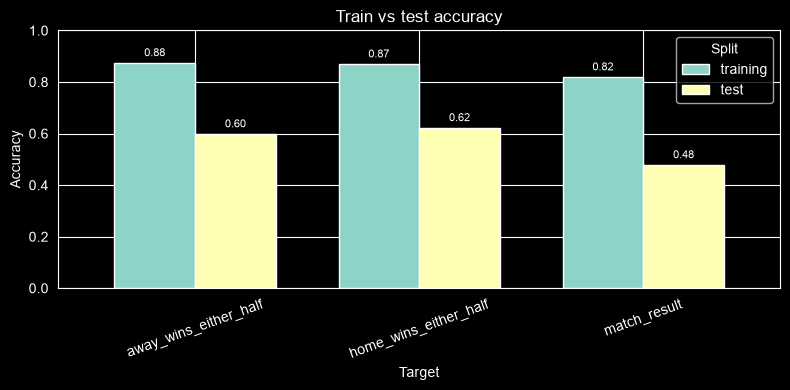

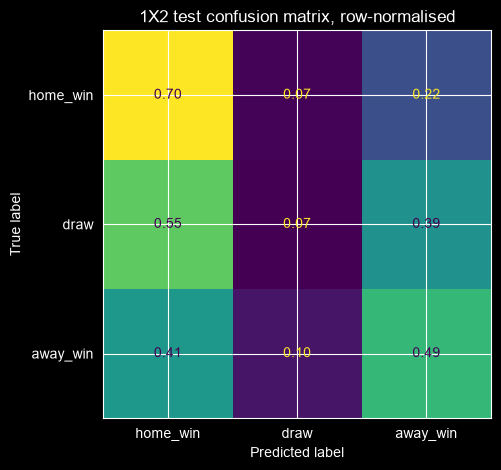

1X2 class-level test metrics


,precision,recall,f1-score,support
home_win,0.541,0.705,0.612,508.000
draw,0.204,0.066,0.100,288.000
away_win,0.442,0.492,0.465,362.000
accuracy,0.479,0.479,0.479,0.479
macro avg,0.396,0.421,0.392,1158.000
weighted avg,0.426,0.479,0.439,1158.000


Either-half positive-class metrics


,target,split,positive_precision,positive_recall,positive_f1,positive_support
0,home_wins_either_half,training,0.863,0.922,0.891,7065.0
1,home_wins_either_half,test,0.666,0.710,0.688,677.0
2,away_wins_either_half,training,0.893,0.830,0.860,5661.0
3,away_wins_either_half,test,0.570,0.516,0.542,531.0


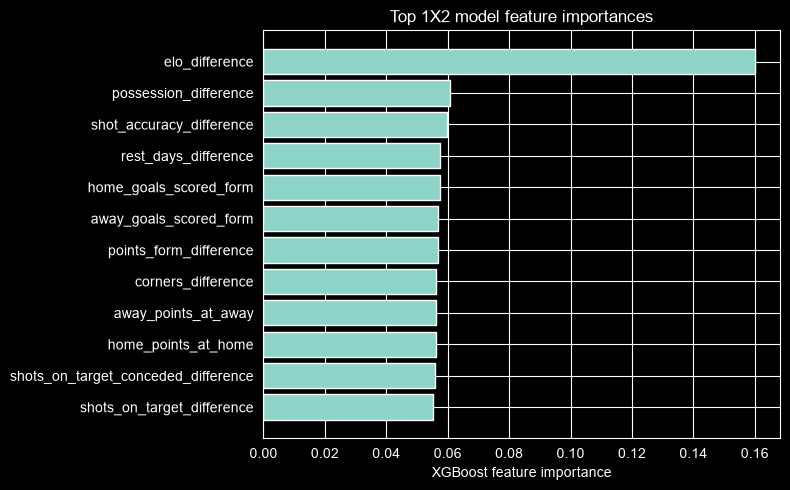

Top feature importances for the 1X2 model


,feature,importance
0,elo_difference,0.1602
1,possession_difference,0.0608
2,shot_accuracy_difference,0.0598
3,rest_days_difference,0.0576
4,home_goals_scored_form,0.0575
5,away_goals_scored_form,0.0570
6,points_form_difference,0.0568
7,corners_difference,0.0563
8,away_points_at_away,0.0563
9,home_points_at_home,0.0561


In [8]:
model_generalisation_table = (
    accuracy_pivot_table
    .assign(train_test_gap=lambda frame: frame["training"] - frame["test"])
    .sort_values("train_test_gap", ascending=False)
)

print("Train/test generalisation gap")
display(model_generalisation_table.round(3))

figure, axis = pyplot.subplots(figsize=(8, 4))
accuracy_pivot_table[["training", "test"]].plot(kind="bar", ax=axis, width=0.72)
axis.set_title("Train vs test accuracy")
axis.set_ylabel("Accuracy")
axis.set_xlabel("Target")
axis.set_ylim(0, 1)
axis.tick_params(axis="x", rotation=20)
axis.legend(title="Split")
for container in axis.containers:
    axis.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
pyplot.tight_layout()
pyplot.show()

result_label_order = [match_result_labels[result_code] for result_code in [0, 1, 2]]
test_result_predictions = prediction_store[("match_result", "test")]
normalised_confusion = confusion_matrix(
    test_matches["match_result"],
    test_result_predictions,
    labels=[0, 1, 2],
    normalize="true",
)
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=normalised_confusion,
    display_labels=result_label_order,
)
figure, axis = pyplot.subplots(figsize=(5.6, 4.8))
confusion_display.plot(ax=axis, values_format=".2f", colorbar=False)
axis.set_title("1X2 test confusion matrix, row-normalised")
pyplot.tight_layout()
pyplot.show()

match_result_report_table = pandas.DataFrame(
    classification_report(
        test_matches["match_result"],
        test_result_predictions,
        labels=[0, 1, 2],
        target_names=result_label_order,
        output_dict=True,
        zero_division=0,
    )
).transpose()
print("1X2 class-level test metrics")
display(match_result_report_table.round(3))

binary_report_records = []
for target_name in binary_target_names:
    for split_name, split_frame in [("training", training_matches), ("test", test_matches)]:
        binary_report = classification_report(
            split_frame[target_name],
            prediction_store[(target_name, split_name)],
            labels=[0, 1],
            output_dict=True,
            zero_division=0,
        )
        binary_report_records.append({
            "target": target_name,
            "split": split_name,
            "positive_precision": binary_report["1"]["precision"],
            "positive_recall": binary_report["1"]["recall"],
            "positive_f1": binary_report["1"]["f1-score"],
            "positive_support": binary_report["1"]["support"],
        })

binary_report_table = pandas.DataFrame(binary_report_records)
print("Either-half positive-class metrics")
display(binary_report_table.round(3))

feature_importance_table = (
    pandas.DataFrame({
        "feature": feature_names,
        "importance": trained_models["match_result"].feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

figure, axis = pyplot.subplots(figsize=(8, 5))
top_feature_importance = feature_importance_table.head(12).sort_values("importance")
axis.barh(top_feature_importance["feature"], top_feature_importance["importance"])
axis.set_title("Top 1X2 model feature importances")
axis.set_xlabel("XGBoost feature importance")
pyplot.tight_layout()
pyplot.show()

print("Top feature importances for the 1X2 model")
display(feature_importance_table.head(12).round(4))

## 9. Decision Pipeline

The model outputs proper 1X2 probabilities that sum to 1. Outright home
and away picks use probability plus margin. Either-half picks use
probability only, because the two either-half targets are not mutually
exclusive.

In [9]:
decision_labels = [
    "home",
    "away",
    "home win either half",
    "away win either half",
    "skip",
]
print("Decision labels:", decision_labels)
print("Decision thresholds:", decision_thresholds)


def predict_match_result_probabilities(match_result_model, feature_matrix):
    probabilities = match_result_model.predict_proba(feature_matrix)
    probability_frame = pandas.DataFrame(index=feature_matrix.index)
    for class_position, class_label in enumerate(match_result_model.classes_):
        result_name = match_result_labels[int(class_label)]
        probability_frame[f"{result_name}_probability"] = probabilities[:, class_position]
    return probability_frame


def score_model_probabilities(match_frame, models_by_target):
    scored_matches = match_frame[[
        "season",
        "country",
        "competition",
        "date_utc",
        "home_team",
        "away_team",
        "match_result",
        "home_win",
        "draw",
        "away_win",
        "home_wins_either_half",
        "away_wins_either_half",
    ]].copy()
    feature_matrix = match_frame[feature_names]

    result_probabilities = predict_match_result_probabilities(
        models_by_target["match_result"],
        feature_matrix,
    )
    scored_matches = scored_matches.join(result_probabilities)
    scored_matches["home_wins_either_half_probability"] = (
        models_by_target["home_wins_either_half"].predict_proba(feature_matrix)[:, 1]
    )
    scored_matches["away_wins_either_half_probability"] = (
        models_by_target["away_wins_either_half"].predict_proba(feature_matrix)[:, 1]
    )
    return scored_matches.reset_index(drop=True)


def make_decision(
    home_win_probability,
    draw_probability,
    away_win_probability,
    home_wins_either_half_probability,
    away_wins_either_half_probability,
):
    result_probabilities = {
        "home": home_win_probability,
        "draw": draw_probability,
        "away": away_win_probability,
    }
    ordered_results = sorted(result_probabilities.items(), key=lambda item: item[1], reverse=True)
    leading_result, leading_result_probability = ordered_results[0]
    runner_up_result_probability = ordered_results[1][1]
    result_probability_gap = leading_result_probability - runner_up_result_probability

    if (
        leading_result in {"home", "away"}
        and leading_result_probability >= decision_thresholds["minimum_outright_probability"]
        and result_probability_gap >= decision_thresholds["minimum_outright_margin"]
    ):
        return {
            "decision": leading_result,
            "decision_probability": leading_result_probability,
        }

    either_half_probabilities = {
        "home win either half": home_wins_either_half_probability,
        "away win either half": away_wins_either_half_probability,
    }
    either_half_decision, either_half_probability = max(
        either_half_probabilities.items(),
        key=lambda item: item[1],
    )

    if either_half_probability >= decision_thresholds["minimum_either_half_probability"]:
        return {
            "decision": either_half_decision,
            "decision_probability": either_half_probability,
        }

    return {
        "decision": "skip",
        "decision_probability": numpy.nan,
    }


def apply_decisions(scored_matches):
    evaluation = scored_matches.copy()
    decision_records = pandas.DataFrame([
        make_decision(
            match_record.home_win_probability,
            match_record.draw_probability,
            match_record.away_win_probability,
            match_record.home_wins_either_half_probability,
            match_record.away_wins_either_half_probability,
        )
        for match_record in evaluation.itertuples(index=False)
    ])
    evaluation = pandas.concat([evaluation.reset_index(drop=True), decision_records], axis=1)

    evaluation["bet_won"] = pandas.Series(pandas.NA, index=evaluation.index, dtype="boolean")
    evaluation.loc[evaluation["decision"].eq("home"), "bet_won"] = evaluation["home_win"].eq(1)
    evaluation.loc[evaluation["decision"].eq("away"), "bet_won"] = evaluation["away_win"].eq(1)
    evaluation.loc[evaluation["decision"].eq("home win either half"), "bet_won"] = (
        evaluation["home_wins_either_half"].eq(1)
    )
    evaluation.loc[evaluation["decision"].eq("away win either half"), "bet_won"] = (
        evaluation["away_wins_either_half"].eq(1)
    )
    return evaluation


def summarize_decisions(evaluation):
    summary_records = []
    total_matches = len(evaluation)

    for decision_label in decision_labels[:-1]:
        selected_decisions = evaluation[evaluation["decision"].eq(decision_label)]
        summary_records.append({
            "decision": decision_label,
            "picks": len(selected_decisions),
            "coverage": len(selected_decisions) / total_matches if total_matches else numpy.nan,
            "precision": (
                selected_decisions["bet_won"].astype(float).mean()
                if len(selected_decisions)
                else numpy.nan
            ),
            "skip_rate": numpy.nan,
        })

    selected_bets = evaluation[~evaluation["decision"].eq("skip")]
    summary_records.append({
        "decision": "combined slate",
        "picks": len(selected_bets),
        "coverage": len(selected_bets) / total_matches if total_matches else numpy.nan,
        "precision": selected_bets["bet_won"].astype(float).mean() if len(selected_bets) else numpy.nan,
        "skip_rate": numpy.nan,
    })
    skipped_matches = evaluation[evaluation["decision"].eq("skip")]
    summary_records.append({
        "decision": "skip",
        "picks": len(skipped_matches),
        "coverage": len(skipped_matches) / total_matches if total_matches else numpy.nan,
        "precision": numpy.nan,
        "skip_rate": len(skipped_matches) / total_matches if total_matches else numpy.nan,
    })
    return pandas.DataFrame(summary_records)

Decision labels: ['home', 'away', 'home win either half', 'away win either half', 'skip']
Decision thresholds: {'minimum_outright_probability': 0.65, 'minimum_outright_margin': 0.2, 'minimum_either_half_probability': 0.7}


## 10. Test Evaluation Summary

The final test set is scored with the trained models and hardcoded decision
thresholds. Precision here is measured only on rows where the pipeline makes
a decision; `skip` means the model abstained because the probabilities did
not clear the decision threshold.

Decision summary on the test set


,decision,picks,coverage,precision,skip_rate
0,home,260,0.225,0.638,NaN
1,away,97,0.084,0.577,NaN
2,home win either half,142,0.123,0.577,NaN
3,away win either half,118,0.102,0.585,NaN
4,combined slate,617,0.533,0.605,NaN
5,skip,541,0.467,NaN,0.467


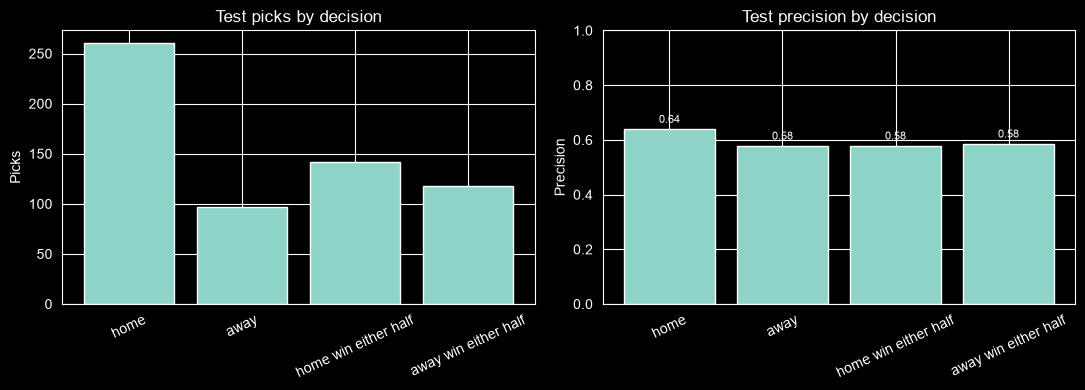

Highest-confidence test decisions


,season,country,competition,date_utc,home_team,away_team,match_result,home_win,draw,away_win,home_wins_either_half,away_wins_either_half,home_win_probability,draw_probability,away_win_probability,home_wins_either_half_probability,away_wins_either_half_probability,decision,decision_probability,bet_won
860,2025-2026,italy,Serie A,2026-04-17 18:45:00,inter,cagliari,0,1,0,0,1,0,0.588274,0.392960,0.018766,0.986396,0.166773,home win either half,0.986396,True
18,2025-2026,spain,La Liga,2026-01-03 17:30:00,elche,villarreal,2,0,0,1,0,1,0.321812,0.154104,0.524084,0.425678,0.981032,away win either half,0.981032,True
462,2025-2026,france,Ligue 1,2026-02-21 20:05:00,psg,metz,0,1,0,0,1,0,0.980394,0.006174,0.013432,0.990657,0.289109,home,0.980394,True
715,2025-2026,germany,Bundesliga,2026-03-21 14:30:00,bayern_munich,union_berlin,0,1,0,0,1,0,0.975800,0.010171,0.014029,0.988100,0.440062,home,0.975800,True
218,2025-2026,spain,La Liga,2026-01-25 15:15:00,barcelona,oviedo,0,1,0,0,1,0,0.971959,0.011655,0.016386,0.951859,0.151918,home,0.971959,True
165,2025-2026,europe,UEFA Champions League,2026-01-21 20:00:00,bayern_munich,royale_union_sg,0,1,0,0,1,0,0.971715,0.023738,0.004547,0.982804,0.144318,home,0.971715,True
917,2025-2026,italy,Serie A,2026-04-25 13:00:00,parma,pisa,0,1,0,0,1,0,0.649744,0.204044,0.146212,0.968379,0.513227,home win either half,0.968379,True
818,2025-2026,germany,Bundesliga,2026-04-11 16:30:00,st._pauli,bayern_munich,2,0,0,1,0,1,0.020997,0.012506,0.966497,0.037409,0.995399,away,0.966497,True
997,2025-2026,italy,Serie A,2026-05-03 16:00:00,juventus,verona,1,0,1,0,1,1,0.964440,0.024781,0.010779,0.935212,0.334787,home,0.964440,False
289,2025-2026,germany,Bundesliga,2026-01-31 17:30:00,hamburger_sv,bayern_munich,1,0,1,0,0,0,0.034647,0.461612,0.503741,0.382029,0.960765,away win either half,0.960765,False


In [10]:
test_scored_matches = score_model_probabilities(test_matches, trained_models)
test_evaluation_table = apply_decisions(test_scored_matches)
decision_summary_table = summarize_decisions(test_evaluation_table)

print("Decision summary on the test set")
display(decision_summary_table.round(3))

decision_plot_table = decision_summary_table[
    ~decision_summary_table["decision"].isin(["combined slate", "skip"])
].copy()

figure, axes = pyplot.subplots(1, 2, figsize=(11, 4))
axes[0].bar(decision_plot_table["decision"], decision_plot_table["picks"])
axes[0].set_title("Test picks by decision")
axes[0].set_ylabel("Picks")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(decision_plot_table["decision"], decision_plot_table["precision"])
axes[1].set_title("Test precision by decision")
axes[1].set_ylabel("Precision")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=25)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3, fontsize=8)

pyplot.tight_layout()
pyplot.show()

print("Highest-confidence test decisions")
display(
    test_evaluation_table
    .sort_values("decision_probability", ascending=False, na_position="last")
    .head(25)
)

## 11. Team-State Store and Fixture Prediction

Future fixtures are converted into the same sixteen features from the
latest stored Elo values, recent team history, and venue-specific history.
Unknown teams or teams without enough stored history are rejected.

In [11]:
trained_team_names = sorted(
    set(training_matches["home_team"]).union(training_matches["away_team"])
)


def build_team_state_store(results_frame):
    if results_frame.empty:
        return {"team_elo_ratings": {}, "team_form": {}, "built_through": None}

    history = results_frame.sort_values(["date_utc", "match_id"]).copy()
    _, team_elo_ratings = add_elo_features(history)
    history_team_rows = make_team_match_rows(history)
    team_form = {}
    for team_name, team_history in history_team_rows.groupby("team"):
        ordered_team_history = team_history.sort_values(["date_utc", "match_id"]).copy()
        team_form[team_name] = {
            "recent_matches": ordered_team_history.tail(window).copy(),
            "recent_home_matches": ordered_team_history[ordered_team_history["venue"].eq("home")].tail(window).copy(),
            "recent_away_matches": ordered_team_history[ordered_team_history["venue"].eq("away")].tail(window).copy(),
            "last_fixture_date": ordered_team_history["date_utc"].max(),
        }

    return {
        "team_elo_ratings": team_elo_ratings,
        "team_form": team_form,
        "built_through": history["date_utc"].max(),
    }


def validate_known_teams(home_team, away_team, known_team_names=trained_team_names):
    unknown_team_names = [
        team_name
        for team_name in [home_team, away_team]
        if team_name not in known_team_names
    ]
    if unknown_team_names:
        raise ValueError(
            "Cannot predict fixtures for team names that were not present in training data: "
            + ", ".join(unknown_team_names)
        )


def state_mean(team_state_store, team_name, history_bucket, metric_name):
    recent_history = team_state_store["team_form"].get(team_name, {}).get(history_bucket)
    if recent_history is None or len(recent_history) < window:
        raise ValueError(
            f"Cannot build {metric_name} for {team_name}: fewer than {window} "
            f"matches available in {history_bucket}."
        )
    metric_value = pandas.to_numeric(recent_history[metric_name].tail(window), errors="coerce").mean()
    if pandas.isna(metric_value):
        raise ValueError(f"Cannot build {metric_name} for {team_name}: stored values are missing.")
    return float(metric_value)


def state_rest_days(team_state_store, team_name, fixture_date):
    last_fixture_date = team_state_store["team_form"].get(team_name, {}).get("last_fixture_date")
    if last_fixture_date is None or pandas.isna(last_fixture_date):
        raise ValueError(f"Cannot build rest days for {team_name}: no previous fixture found.")
    return float((fixture_date - last_fixture_date).days)


def build_fixture_features(home_team, away_team, date, time="15:00", team_state_store=None):
    validate_known_teams(home_team, away_team)

    if team_state_store is None:
        team_state_store = build_team_state_store(matches)

    fixture_date = pandas.to_datetime(f"{date} {time}", errors="coerce")
    if pandas.isna(fixture_date):
        fixture_date = pandas.to_datetime(date)

    elo_ratings = team_state_store["team_elo_ratings"]
    missing_elo_team_names = [
        team_name
        for team_name in [home_team, away_team]
        if team_name not in elo_ratings
    ]
    if missing_elo_team_names:
        raise ValueError(
            "Cannot build Elo features without stored ratings for: "
            + ", ".join(missing_elo_team_names)
        )

    home_elo = float(elo_ratings[home_team])
    away_elo = float(elo_ratings[away_team])

    home_points_form = state_mean(team_state_store, home_team, "recent_matches", "points")
    away_points_form = state_mean(team_state_store, away_team, "recent_matches", "points")
    home_goals_scored_form = state_mean(team_state_store, home_team, "recent_matches", "goals_scored")
    away_goals_scored_form = state_mean(team_state_store, away_team, "recent_matches", "goals_scored")
    home_goals_conceded_form = state_mean(team_state_store, home_team, "recent_matches", "goals_conceded")
    away_goals_conceded_form = state_mean(team_state_store, away_team, "recent_matches", "goals_conceded")
    home_goal_difference_form = state_mean(team_state_store, home_team, "recent_matches", "goal_difference")
    away_goal_difference_form = state_mean(team_state_store, away_team, "recent_matches", "goal_difference")
    home_shots_on_target_form = state_mean(team_state_store, home_team, "recent_matches", "shots_on_target")
    away_shots_on_target_form = state_mean(team_state_store, away_team, "recent_matches", "shots_on_target")
    home_corners_form = state_mean(team_state_store, home_team, "recent_matches", "corners")
    away_corners_form = state_mean(team_state_store, away_team, "recent_matches", "corners")
    home_shot_accuracy_form = state_mean(team_state_store, home_team, "recent_matches", "shot_accuracy")
    away_shot_accuracy_form = state_mean(team_state_store, away_team, "recent_matches", "shot_accuracy")
    home_possession_form = state_mean(team_state_store, home_team, "recent_matches", "possession")
    away_possession_form = state_mean(team_state_store, away_team, "recent_matches", "possession")
    home_fouls_form = state_mean(team_state_store, home_team, "recent_matches", "fouls")
    away_fouls_form = state_mean(team_state_store, away_team, "recent_matches", "fouls")
    home_shots_on_target_conceded_form = state_mean(
        team_state_store,
        home_team,
        "recent_matches",
        "shots_on_target_conceded",
    )
    away_shots_on_target_conceded_form = state_mean(
        team_state_store,
        away_team,
        "recent_matches",
        "shots_on_target_conceded",
    )

    fixture_feature_values = {
        "elo_difference": home_elo - away_elo,
        "home_points_at_home": state_mean(team_state_store, home_team, "recent_home_matches", "points"),
        "away_points_at_away": state_mean(team_state_store, away_team, "recent_away_matches", "points"),
        "home_goals_scored_form": home_goals_scored_form,
        "away_goals_scored_form": away_goals_scored_form,
        "points_form_difference": home_points_form - away_points_form,
        "home_attack_vs_away_defence": home_goals_scored_form - away_goals_conceded_form,
        "away_attack_vs_home_defence": away_goals_scored_form - home_goals_conceded_form,
        "goal_difference_form_gap": home_goal_difference_form - away_goal_difference_form,
        "shots_on_target_difference": home_shots_on_target_form - away_shots_on_target_form,
        "corners_difference": home_corners_form - away_corners_form,
        "rest_days_difference": (
            state_rest_days(team_state_store, home_team, fixture_date)
            - state_rest_days(team_state_store, away_team, fixture_date)
        ),
        "shot_accuracy_difference": home_shot_accuracy_form - away_shot_accuracy_form,
        "possession_difference": home_possession_form - away_possession_form,
        "fouls_difference": home_fouls_form - away_fouls_form,
        "shots_on_target_conceded_difference": (
            home_shots_on_target_conceded_form - away_shots_on_target_conceded_form
        ),
    }
    return pandas.DataFrame([fixture_feature_values])[feature_names]


def predict_fixture(home_team, away_team, date, time="15:00", team_state_store=None, models_by_target=None):
    validate_known_teams(home_team, away_team)

    if team_state_store is None:
        team_state_store = build_team_state_store(matches)
    if models_by_target is None:
        models_by_target = trained_models

    fixture_features = build_fixture_features(
        home_team,
        away_team,
        date,
        time=time,
        team_state_store=team_state_store,
    )

    result_probabilities = predict_match_result_probabilities(
        models_by_target["match_result"],
        fixture_features,
    ).iloc[0].to_dict()
    probability_values = {
        **result_probabilities,
        "home_wins_either_half_probability": float(
            models_by_target["home_wins_either_half"].predict_proba(fixture_features)[:, 1][0]
        ),
        "away_wins_either_half_probability": float(
            models_by_target["away_wins_either_half"].predict_proba(fixture_features)[:, 1][0]
        ),
    }
    decision = make_decision(
        probability_values["home_win_probability"],
        probability_values["draw_probability"],
        probability_values["away_win_probability"],
        probability_values["home_wins_either_half_probability"],
        probability_values["away_wins_either_half_probability"],
    )

    return pandas.DataFrame([{
        "date": pandas.to_datetime(date).date(),
        "time": time,
        "home_team": home_team,
        "away_team": away_team,
        **probability_values,
        **decision,
    }])


predict_fixture("lens", "lyon", "2026-08-15")

,date,time,home_team,away_team,home_win_probability,draw_probability,away_win_probability,home_wins_either_half_probability,away_wins_either_half_probability,decision,decision_probability
0,2026-08-15,15:00,lens,lyon,0.580744,0.148051,0.271205,0.658719,0.333418,skip,NaN


## 12. Historical Fixture Demo

Each demo prediction rebuilds state from matches before that fixture's
kickoff only.

In [12]:
demo_fixtures = matches[matches["date_utc"] >= split_date].head(5)
demo_predictions = []

for fixture_record in demo_fixtures.itertuples(index=False):
    state_before_fixture = build_team_state_store(matches[matches["date_utc"] < fixture_record.date_utc])
    prediction = predict_fixture(
        fixture_record.home_team,
        fixture_record.away_team,
        fixture_record.date_utc.strftime("%Y-%m-%d"),
        fixture_record.date_utc.strftime("%H:%M"),
        team_state_store=state_before_fixture,
    )
    prediction["competition"] = fixture_record.competition
    prediction["actual_match_result"] = match_result_labels[fixture_record.match_result]
    prediction["actual_home_wins_either_half"] = fixture_record.home_wins_either_half
    prediction["actual_away_wins_either_half"] = fixture_record.away_wins_either_half
    demo_predictions.append(prediction)

historical_fixture_demo = (
    pandas.concat(demo_predictions, ignore_index=True)
    if demo_predictions
    else pandas.DataFrame()
)

print("Historical fixture prediction demo")
display(historical_fixture_demo)

Historical fixture prediction demo


,date,time,home_team,away_team,home_win_probability,draw_probability,away_win_probability,home_wins_either_half_probability,away_wins_either_half_probability,decision,decision_probability,competition,actual_match_result,actual_home_wins_either_half,actual_away_wins_either_half
0,2026-01-01,17:30,crystal_palace,fulham,0.558619,0.160650,0.280731,0.576549,0.571058,skip,NaN,Premier League,draw,1,1
1,2026-01-01,17:30,liverpool,leeds,0.656360,0.207135,0.136505,0.876485,0.120516,home,0.656360,Premier League,draw,0,0
2,2026-01-01,20:00,brentford,tottenham,0.601407,0.253399,0.145194,0.728634,0.239429,home win either half,0.728634,Premier League,draw,0,0
3,2026-01-01,20:00,sunderland,manchester_city,0.136347,0.269834,0.593819,0.164255,0.557255,skip,NaN,Premier League,draw,0,0
4,2026-01-02,19:45,toulouse,lens,0.072729,0.173024,0.754247,0.059522,0.662598,away,0.754247,Ligue 1,away_win,0,1


## 13. Save Artifact

Save the multiclass 1X2 model, either-half models, feature names, hardcoded
decision thresholds, Elo settings, trained team names, and current team
state.

In [13]:
team_state_store = build_team_state_store(matches)

artifact = {
    "model_family": "XGBClassifier",
    "model_setup": "one multiclass 1X2 model plus two binary either-half models",
    "xgboost_parameters": xgboost_parameters,
    "trained_models": trained_models,
    "feature_names": feature_names,
    "target_names": target_names,
    "binary_target_names": binary_target_names,
    "match_result_labels": match_result_labels,
    "decision_thresholds": decision_thresholds,
    "window": window,
    "minimum_team_matches": minimum_team_matches,
    "initial_elo": initial_elo,
    "elo_k": elo_k,
    "home_advantage": home_advantage,
    "split_date": split_date,
    "trained_team_names": trained_team_names,
    "team_state_store": team_state_store,
    "model_accuracy_table": model_accuracy_table,
    "accuracy_pivot_table": accuracy_pivot_table,
    "model_generalisation_table": model_generalisation_table,
    "match_result_report_table": match_result_report_table,
    "binary_report_table": binary_report_table,
    "feature_importance_table": feature_importance_table,
    "decision_summary_table": decision_summary_table,
    "test_evaluation_table": test_evaluation_table,
    "competition_counts": matches["competition"].value_counts().rename("count").to_frame(),
    "team_filter_summary": team_filter_summary,
    "load_summary": load_summary,
    "data_path": str(data_path),
}

models_directory.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, artifact_path)
reloaded_artifact = joblib.load(artifact_path)

print(f"Saved artifact to {artifact_path}")
print("Reloaded artifact keys:", sorted(reloaded_artifact.keys()))
print("Reloaded model setup:", reloaded_artifact["model_setup"])
print("Reloaded feature count:", len(reloaded_artifact["feature_names"]))

Saved artifact to C:\PROJECTS\Python\ML\betting\models\match_1x2_pred.joblib
Reloaded artifact keys: ['accuracy_pivot_table', 'binary_report_table', 'binary_target_names', 'competition_counts', 'data_path', 'decision_summary_table', 'decision_thresholds', 'elo_k', 'feature_importance_table', 'feature_names', 'home_advantage', 'initial_elo', 'load_summary', 'match_result_labels', 'match_result_report_table', 'minimum_team_matches', 'model_accuracy_table', 'model_family', 'model_generalisation_table', 'model_setup', 'split_date', 'target_names', 'team_filter_summary', 'team_state_store', 'test_evaluation_table', 'trained_models', 'trained_team_names', 'window', 'xgboost_parameters']
Reloaded model setup: one multiclass 1X2 model plus two binary either-half models
Reloaded feature count: 16
